In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import os
import pandas as pd
import cv2


In [43]:
DIR = os.listdir('C:\ACML\Radiography')
print(DIR)

['test', 'train', 'val']


In [44]:
train_folder = r"C:\ACML\Radiography\train"
val_folder = r"C:\ACML\Radiography\val"
test_folder = r"C:\ACML\Radiography\test"

In [53]:
labels = ["NORMAL", "PNEUMONIA"] # each folder has two sub folder name "PNEUMONIA", "NORMAL"
IMG_SIZE = 152 # resize image I will make this 152 when doing preprocessing

def get_data_train(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label) #look for subfolders N and P
        class_num = labels.index(label) #0 for NORMAL, 1 for PNEUMONIA
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)#convert to grayscale
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))#have to make this 152
                data.append([new_array, class_num])
            except Exception as e:
                print(e)
    return np.array(data)

In [54]:
train = get_data_train(train_folder)
test = get_data_train(test_folder)
val = get_data_train(val_folder)

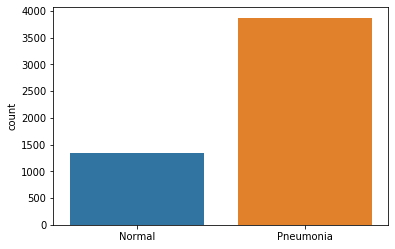

In [55]:
#need to check how many images in each class
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
        
sns.countplot(x = l) #specifically state which axis data belongs to
plt.show()

In [56]:
#currently our data is in pairs [immage_data, label_number] but for training
#requre images X and answers y to be separate
#This is feature label separation
#After this X will have all images and y will have label(0 or 1)
X_train = []
y_train = []

X_val = []
y_val = []

X_test = []
y_test = []

for feature, label in train:
    X_train.append(feature)
    y_train.append(label)

for feature, label in test:
    X_test.append(feature)
    y_test.append(label)
    
for feature, label in val:
    X_val.append(feature)
    y_val.append(label)

In [57]:
#Normalization - scale numeric data to be between 0 or 1
#We are working with pixels, so between 0 to 255
X_train = np.array(X_train) / 255.0
X_val = np.array(X_val) / 255.0
X_test = np.array(X_test) / 255.0

In [61]:
X_train.shape
#shows number images in dataset, height and width of each

(5216, 152, 152)

In [ ]:
#reshape since CNNs expect a 4D tensor. Add a "Channel" at the end
#to know of image is in color(3) or grayscale(1)
#even make the labels 4D

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)#-1 shortcut telling NumPy to figure out number of images automatically
y_train = np.array(y_train)

X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_val = np.array(y_val)

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_test = np.array(y_test)
